✅ Đã lưu: VinRosie_C.jpg


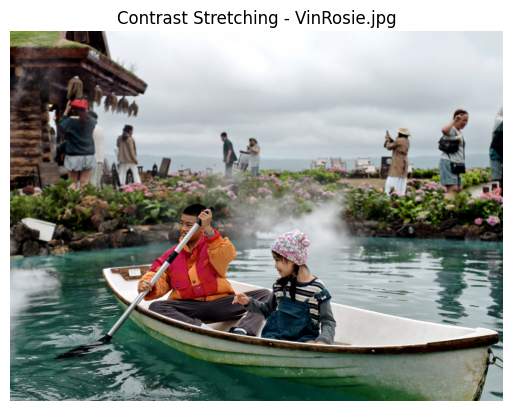

In [ ]:
#áp dụng C

import os
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from skimage.exposure import rescale_intensity

input_folder = 'anhcanh'
output_folder = 'anhcanh_out'
os.makedirs(output_folder, exist_ok=True)

def contrast_stretching(img):
    p2, p98 = np.percentile(img, (2, 98))
    stretched = rescale_intensity(img, in_range=(p2, p98))
    return (stretched * 255).astype(np.uint8) if stretched.max() <= 1 else stretched

# Lặp qua từng ảnh trong thư mục
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp', '.tif')):
        img_path = os.path.join(input_folder, filename)
        img = iio.imread(img_path)

        # Áp dụng contrast stretching
        result = contrast_stretching(img)

        # Lưu ảnh kết quả
        save_name = f"{os.path.splitext(filename)[0]}_C.jpg"
        iio.imwrite(os.path.join(output_folder, save_name), result)
        print(f"✅ Đã lưu: {save_name}")

        # Hiển thị ảnh kết quả
        plt.imshow(result)
        plt.axis('off')
        plt.title(f"Contrast Stretching - {filename}")
        plt.show()


✅ Đã lưu: VinRosie_G0.7.jpg


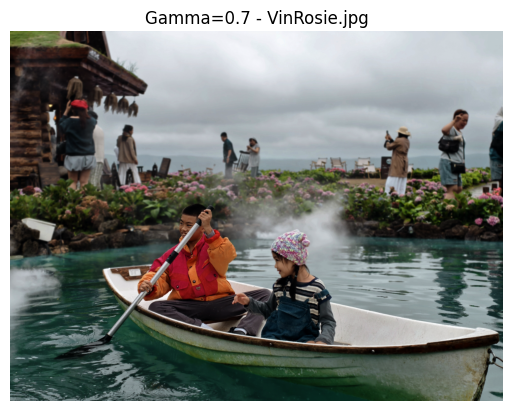

In [19]:
# áp dụng Gamma Correction (gamma = 2.2)

import os
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from skimage.util import img_as_float
from skimage import img_as_ubyte

input_folder = 'anhcanh'
output_folder = 'anhcanh_out'
os.makedirs(output_folder, exist_ok=True)

# Hàm gamma correction
def gamma_correction(img, gamma):
    img_float = img_as_float(img)        # Chuẩn hóa ảnh về [0,1]
    corrected = np.power(img_float, 1 / gamma)
    return img_as_ubyte(corrected)       # Chuyển về uint8

# Nhập gamma từ người dùng
gamma_value = float(input("Nhập giá trị gamma (ví dụ: 2.2): "))

# Lặp qua tất cả ảnh trong thư mục
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp', '.tif')):
        img_path = os.path.join(input_folder, filename)
        img = iio.imread(img_path)

        # Áp dụng gamma correction với giá trị gamma nhập
        result = gamma_correction(img, gamma_value)

        # Lưu kết quả
        save_name = f"{os.path.splitext(filename)[0]}_G{gamma_value}.jpg"
        iio.imwrite(os.path.join(output_folder, save_name), result)
        print(f"✅ Đã lưu: {save_name}")

        # Hiển thị ảnh kết quả
        plt.imshow(result)
        plt.axis('off')
        plt.title(f"Gamma={gamma_value} - {filename}")
        plt.show()



✅ Đã lưu: VinRosie_Log.jpg


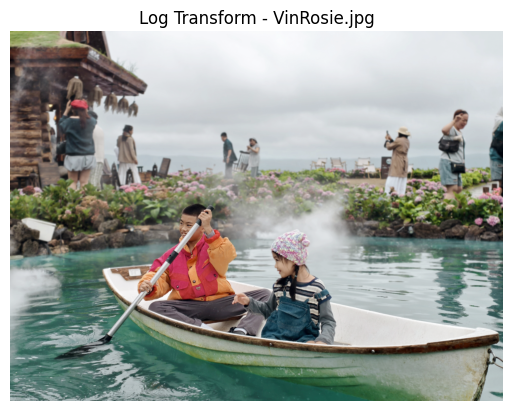

In [13]:
# Áp dụng Log Transformation

import os
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from skimage.util import img_as_float
from skimage import img_as_ubyte

input_folder = 'anhcanh'
output_folder = 'anhcanh_out'
os.makedirs(output_folder, exist_ok=True)

def log_transform(img):
    # Chuẩn hóa ảnh về [0,1]
    img_float = img_as_float(img)
    # Áp dụng log transform: s = c * log(1 + r)
    c = 1 / np.log(1 + 1)  # vì r ∈ [0,1], log(2) ~ 0.693
    log_img = c * np.log(1 + img_float)
    # Chuyển về uint8
    return img_as_ubyte(log_img)

# Lặp qua tất cả các ảnh trong thư mục
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp', '.tif')):
        img_path = os.path.join(input_folder, filename)
        img = iio.imread(img_path)

        # Áp dụng log transform
        result = log_transform(img)

        # Lưu kết quả
        save_name = f"{os.path.splitext(filename)[0]}_Log.jpg"
        iio.imwrite(os.path.join(output_folder, save_name), result)
        print(f"✅ Đã lưu: {save_name}")

        # Hiển thị kết quả
        plt.imshow(result)
        plt.axis('off')
        plt.title(f"Log Transform - {filename}")
        plt.show()


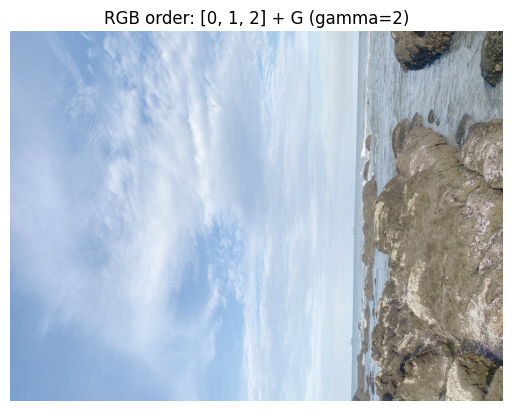

Đã lưu: bin_RGB012_G_2.jpg


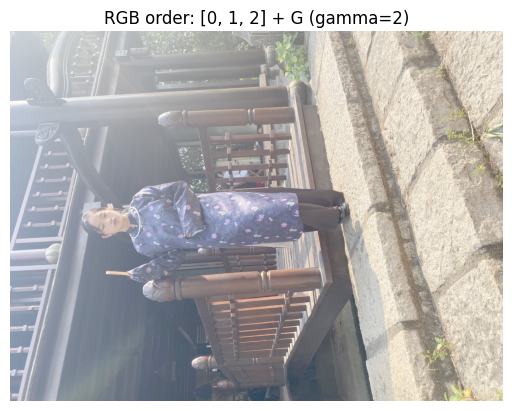

Đã lưu: me_RGB012_G_2.jpg


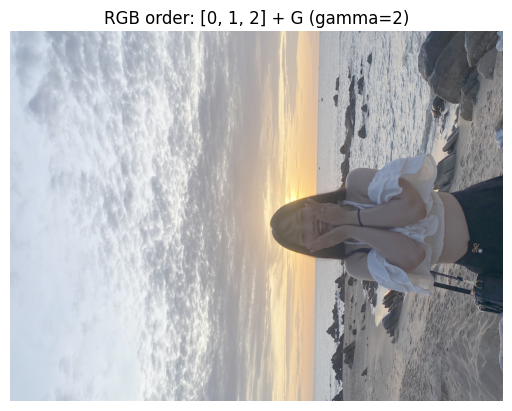

Đã lưu: toi_RGB012_G_2.jpg


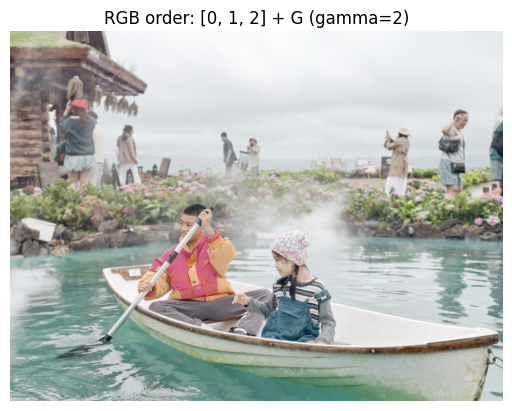

Đã lưu: VinRosie_RGB012_G_2.jpg


In [1]:
#ảnh rgb=[0,1,2] + G

import os
import numpy as np
import imageio.v2 as iio
import matplotlib.pyplot as plt
from skimage import img_as_ubyte, img_as_float

# ===== Thư mục =====
input_folder = 'anhcanh'
output_folder = 'anhcanh_out'
os.makedirs(output_folder, exist_ok=True)

# ===== Hàm Gamma Correction =====
def gamma_correction(img, gamma=2.2):
    img_float = img_as_float(img)       # chuẩn hóa về [0,1]
    corrected = np.power(img_float, 1 / gamma)
    return img_as_ubyte(corrected)

# ===== Cố định RGB order [0,1,2] và biến đổi Gamma Correction =====
rgb_order = [0,1,2]
gamma_value = 2   # hoặc có thể nhập từ người dùng nếu muốn

for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.jpg', '.png', '.bmp', '.jpeg')):
        img_path = os.path.join(input_folder, filename)
        img = iio.imread(img_path)

        # Cố định thứ tự RGB [0,1,2]
        img_rgb = img[:, :, rgb_order]

        # Áp dụng gamma correction cố định
        transformed = gamma_correction(img_rgb, gamma=gamma_value)

        # Hiển thị kết quả
        plt.imshow(transformed)
        plt.title(f"RGB order: {rgb_order} + G (gamma={gamma_value})")
        plt.axis('off')
        plt.show()

        # Lưu ảnh kết quả với tên cố định
        output_name = f"{os.path.splitext(filename)[0]}_RGB012_G_{gamma_value}.jpg"
        output_path = os.path.join(output_folder, output_name)
        iio.imwrite(output_path, transformed)
        print(f"Đã lưu: {output_name}")
